In [1]:
# DAY 3 : Exploratory Data Analysis (EDA)
# GOAL  : Find patterns, understand distributions,
#         get first visual proof of our hypothesis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/cleaned/student_lifestyle_cleaned.csv')

print(f"Clean dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Clean dataset loaded: 1000 rows, 21 columns


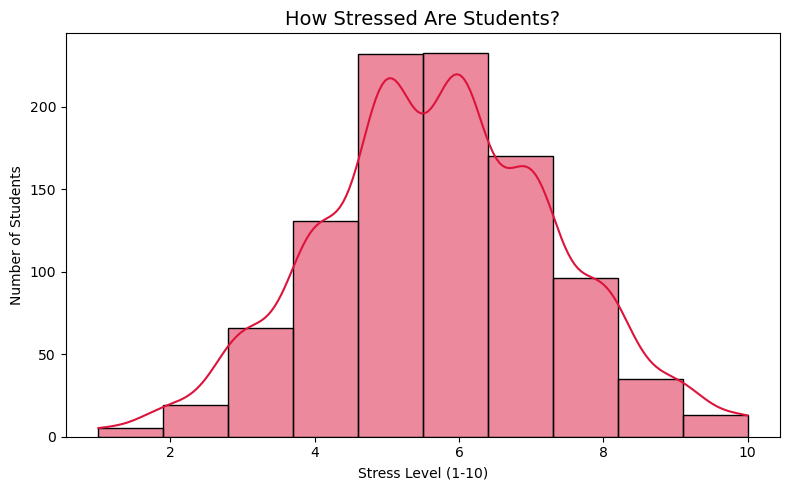

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df['stress_level'], bins=10, kde=True, color='crimson')
plt.title('How Stressed Are Students?', fontsize=14)
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('../reports/figures/01_stress_distribution.png')
plt.show()

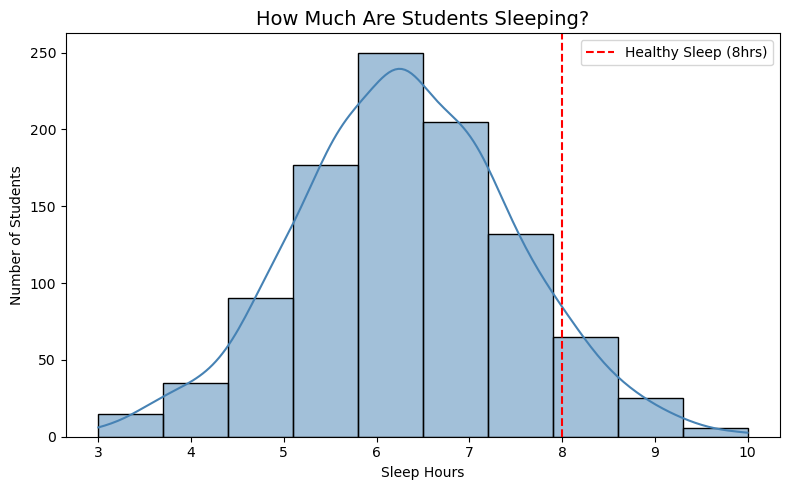

In [3]:
#Seeing how many hours students sleep
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_hours'], bins=10, kde=True, color='steelblue')
plt.title('How Much Are Students Sleeping?', fontsize=14)
plt.xlabel('Sleep Hours')
plt.ylabel('Number of Students')
plt.axvline(x=8, color='red', linestyle='--', label='Healthy Sleep (8hrs)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/02_sleep_distribution.png')
plt.show()

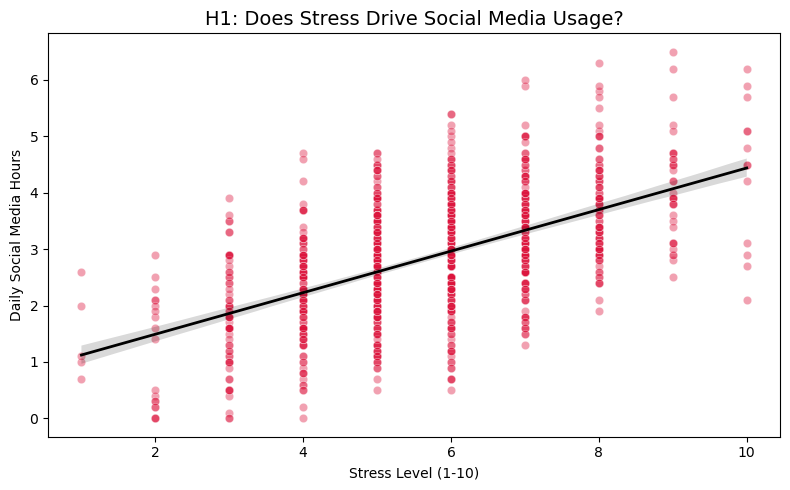

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, 
                x='stress_level', 
                y='daily_social_media_hours',
                alpha=0.4, 
                color='crimson')

# Add a trend line
sns.regplot(data=df,
            x='stress_level',
            y='daily_social_media_hours',
            scatter=False,
            color='black',
            line_kws={'linewidth': 2})

plt.title('H1: Does Stress Drive Social Media Usage?', fontsize=14)
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Daily Social Media Hours')
plt.tight_layout()
plt.savefig('../reports/figures/03_stress_vs_socialmedia.png')
plt.show()

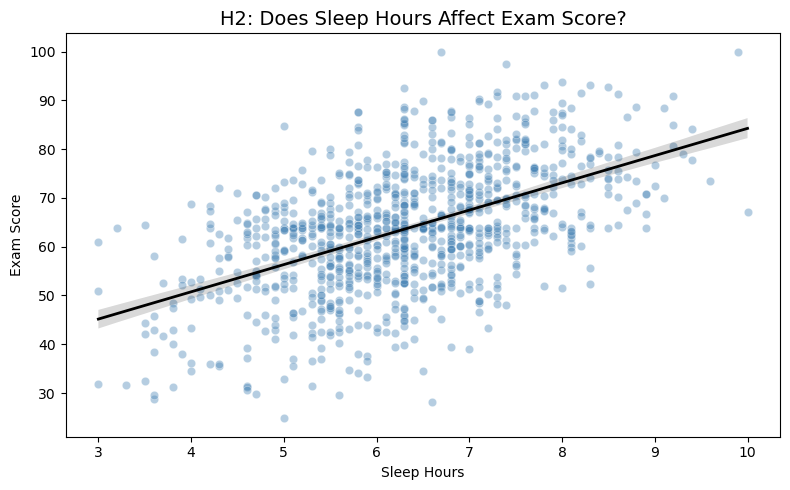

In [5]:
# sleeping less hurts exam scores?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='sleep_hours',
                y='exam_score',
                alpha=0.4,
                color='steelblue')

sns.regplot(data=df,
            x='sleep_hours',
            y='exam_score',
            scatter=False,
            color='black',
            line_kws={'linewidth': 2})

plt.title('H2: Does Sleep Hours Affect Exam Score?', fontsize=14)
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.savefig('../reports/figures/04_sleep_vs_examscore.png')
plt.show()

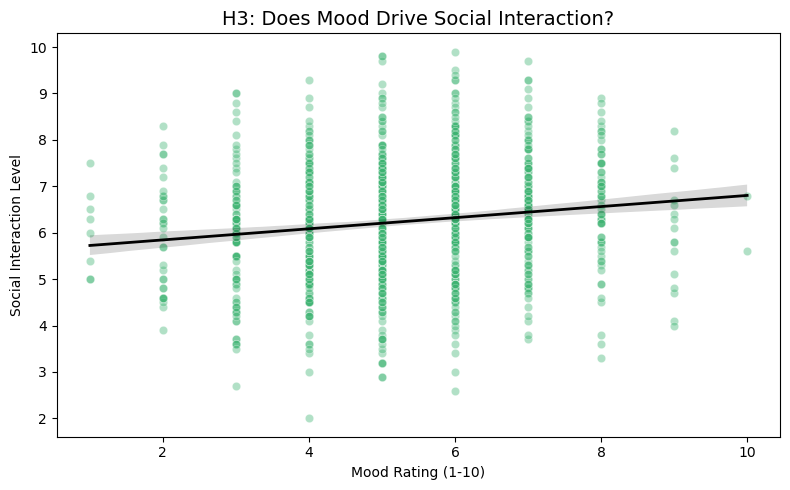

In [6]:
#mood affect how social a student is?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='mood_rating',
                y='social_interaction_level',
                alpha=0.4,
                color='mediumseagreen')

sns.regplot(data=df,
            x='mood_rating',
            y='social_interaction_level',
            scatter=False,
            color='black',
            line_kws={'linewidth': 2})

plt.title('H3: Does Mood Drive Social Interaction?', fontsize=14)
plt.xlabel('Mood Rating (1-10)')
plt.ylabel('Social Interaction Level')
plt.tight_layout()
plt.savefig('../reports/figures/05_mood_vs_social.png')
plt.show()

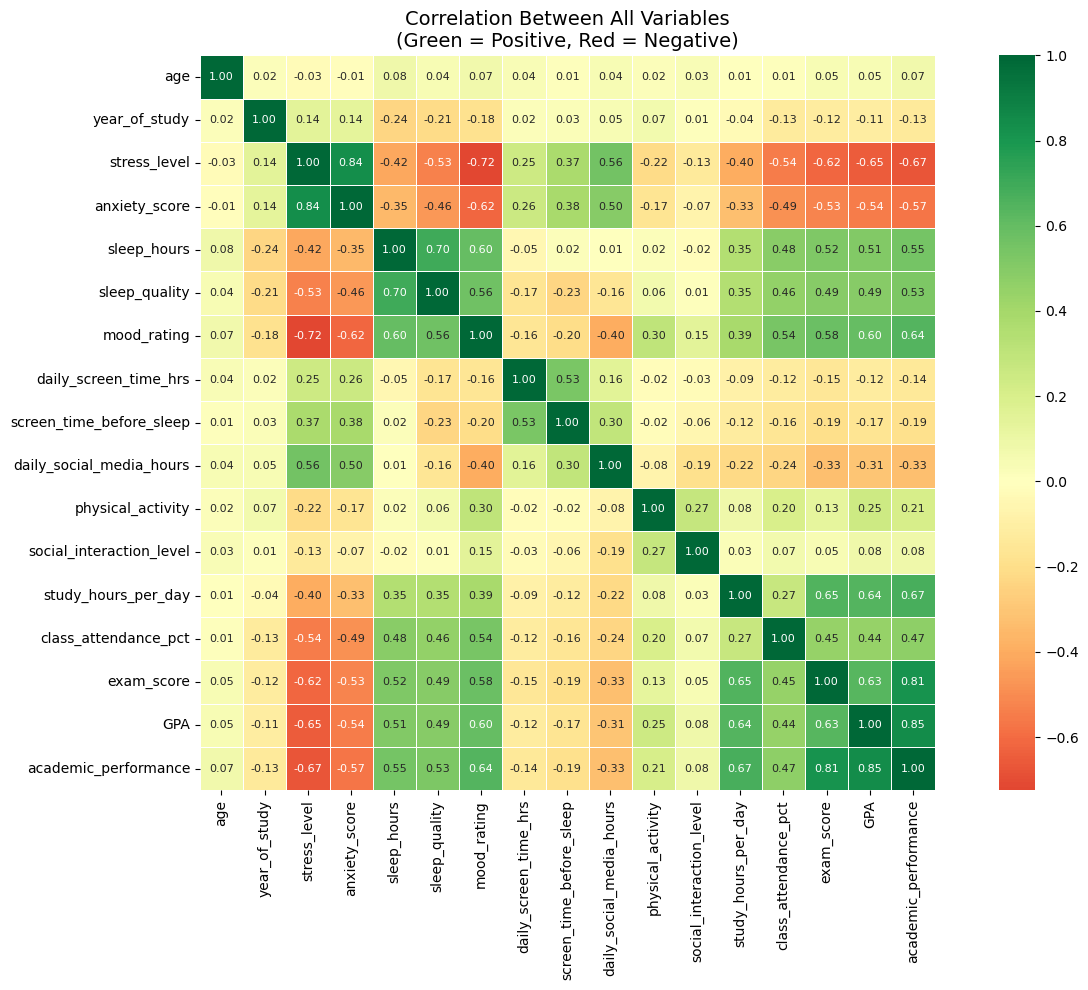

In [7]:
#Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=np.number)
numeric_df = numeric_df.drop(columns=['student_id'])
# Calculate correlation
corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Between All Variables\n(Green = Positive, Red = Negative)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_heatmap.png')
plt.show()

##stress drives social media usage
*Correlation : +0.56* strong

##sleep hours drive exam performance
*Correlation : +0.52* strong 

##mood drives social interaction
*Relationship exists but very small*

##The Heatmap 
*stress_level ; academic_performance = -0.67 
stress_level  ; GPA                  = -0.65 
stress_level  ; exam_score           = -0.62 
mood_rating   ; GPA                  = +0.60 
sleep_hours   ; exam_score           = +0.52 *